<a href="https://colab.research.google.com/github/tatyanakrivonogova/machine-learning-methods/blob/master/%D0%91%D0%BB%D0%BE%D0%BA_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Деревья решений

## Классификационное дерево и Random Forest

Классификационное дерево - дерево, в котором каждый узел проверяет условие на одном из признаков и разделяет входную выборку на части таким образом, чтобы уменьшить разнородность объектов в каждом из дочерних листов. Листья дерева соответствуют итоговым классам.

Random Forest - ансамблевый метод, который строит множество классификационных деревьев на случайных подвыборках данных и случайных подмножествах признаков. Итоговый прогноз определяется голосованием всех деревьев.

### Используемые библиотеки

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.tree import plot_tree

### Датасет

Размерность данных: (1797, 65)
Количество классов: 10
Пример данных:
   pixel_0  pixel_1  pixel_2  pixel_3  pixel_4  pixel_5  pixel_6  pixel_7  \
0      0.0      0.0      5.0     13.0      9.0      1.0      0.0      0.0   
1      0.0      0.0      0.0     12.0     13.0      5.0      0.0      0.0   
2      0.0      0.0      0.0      4.0     15.0     12.0      0.0      0.0   
3      0.0      0.0      7.0     15.0     13.0      1.0      0.0      0.0   
4      0.0      0.0      0.0      1.0     11.0      0.0      0.0      0.0   

   pixel_8  pixel_9  ...  pixel_55  pixel_56  pixel_57  pixel_58  pixel_59  \
0      0.0      0.0  ...       0.0       0.0       0.0       6.0      13.0   
1      0.0      0.0  ...       0.0       0.0       0.0       0.0      11.0   
2      0.0      0.0  ...       0.0       0.0       0.0       0.0       3.0   
3      0.0      8.0  ...       0.0       0.0       0.0       7.0      13.0   
4      0.0      0.0  ...       0.0       0.0       0.0       0.0       2.0   


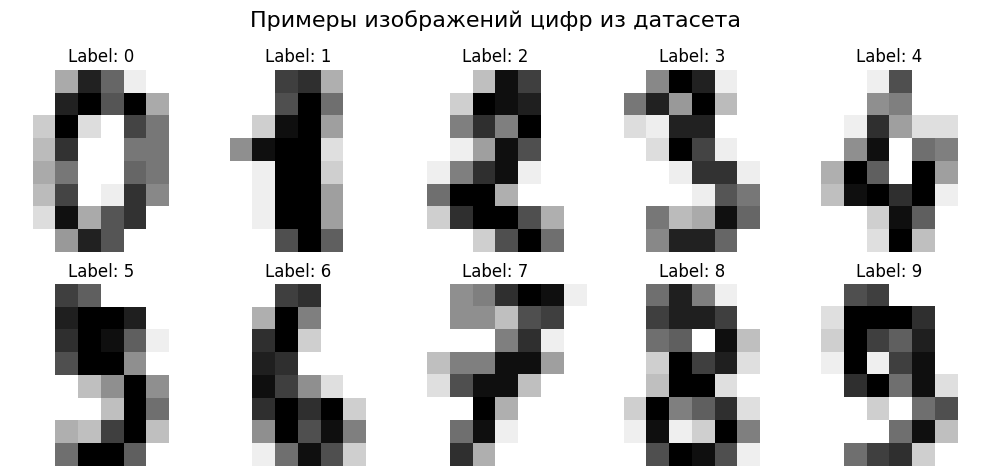

In [ ]:
digits = datasets.load_digits()

df = pd.DataFrame(data=digits.data, columns=[f'pixel_{i}' for i in range(digits.data.shape[1])])
df['target'] = digits.target

print(f"Размерность данных: {df.shape}")
print(f"Количество классов: {df['target'].nunique()}")
print("Пример данных:")
print(df.head())

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='binary')
    ax.set_title(f"Label: {df.loc[i, 'target']}")
    ax.axis('off')
plt.suptitle('Примеры изображений цифр из датасета', fontsize=16)
plt.tight_layout()
plt.show()

### Предварительная обработка датасета

In [ ]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Распределение классов в обучающей выборке:\n{y_train.value_counts().sort_index()}")
print(f"Распределение классов в тестовой выборке:\n{y_test.value_counts().sort_index()}")

Размер обучающей выборки: (1437, 64)
Размер тестовой выборки: (360, 64)
Распределение классов в обучающей выборке:
target
0    142
1    146
2    142
3    146
4    145
5    145
6    145
7    143
8    139
9    144
Name: count, dtype: int64
Распределение классов в тестовой выборке:
target
0    36
1    36
2    35
3    37
4    36
5    37
6    36
7    36
8    35
9    36
Name: count, dtype: int64


### Тепловая карта

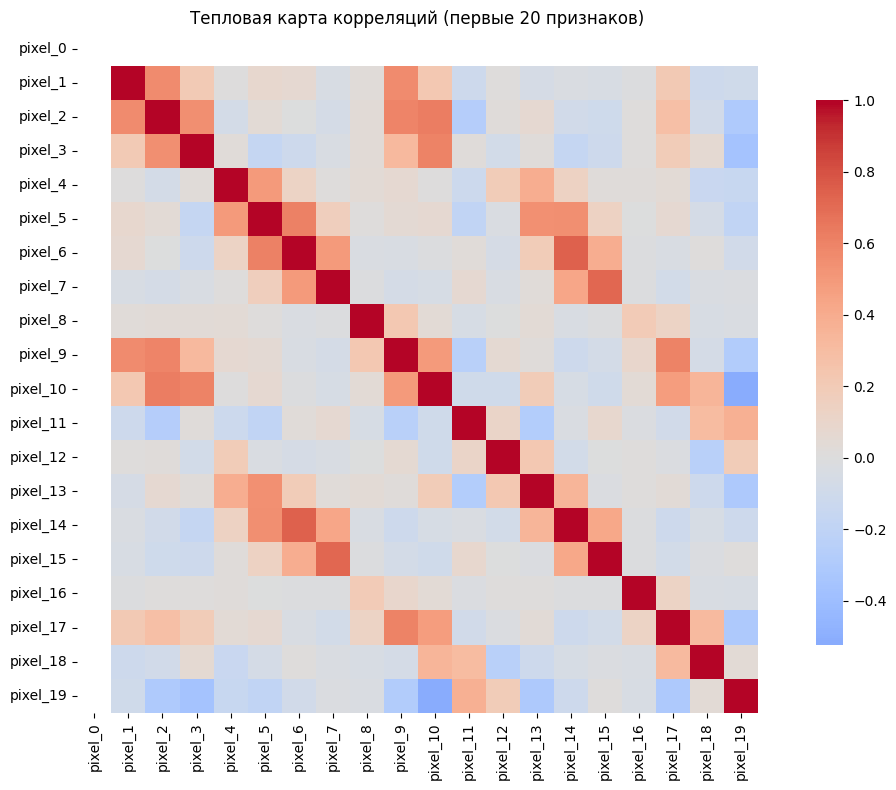

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


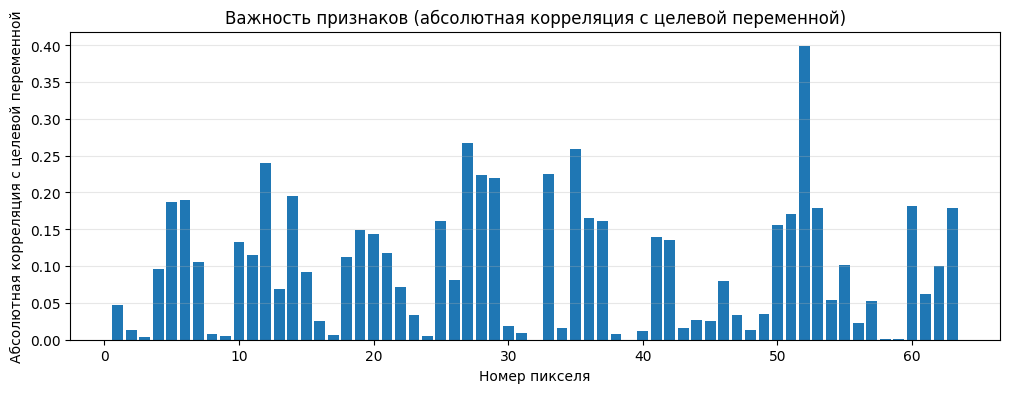

In [ ]:
plt.figure(figsize=(12, 8))
correlation_matrix = X_train.iloc[:, :20].corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0,
            square=True, cbar_kws={"shrink": 0.8})
plt.title('Тепловая карта корреляций (первые 20 признаков)')
plt.tight_layout()
plt.show()

corr_with_target = []
for column in X_train.columns:
    corr = X_train[column].corr(y_train)
    corr_with_target.append(abs(corr))

corr_df = pd.DataFrame({
    'pixel': X_train.columns,
    'correlation': corr_with_target
}).sort_values('correlation', ascending=False)

plt.figure(figsize=(12, 4))
plt.bar(range(len(corr_with_target)), corr_with_target)
plt.xlabel('Номер пикселя')
plt.ylabel('Абсолютная корреляция с целевой переменной')
plt.title('Важность признаков (абсолютная корреляция с целевой переменной)')
plt.grid(axis='y', alpha=0.3)

### Обучение модели

In [ ]:
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5
)
dt_model.fit(X_train, y_train)

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    min_samples_split=2,
    min_samples_leaf=1,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

### Прогнозы модели

In [ ]:
y_pred_dt = dt_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f"\nТочность Decision Tree: {accuracy_dt:.4f}")
print(f"Точность Random Forest: {accuracy_rf:.4f}")


Точность Decision Tree: 0.6667
Точность Random Forest: 0.9611


### Графики выходных результатов

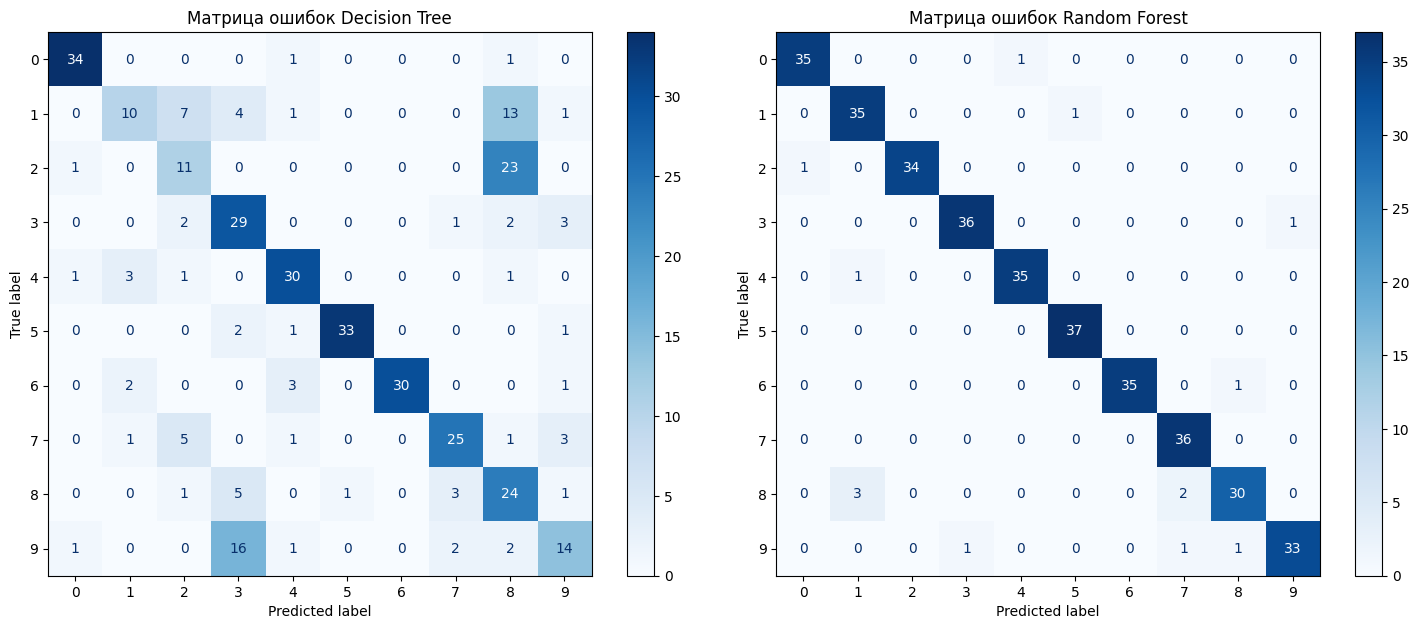

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=range(10))
disp_dt.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title(f'Матрица ошибок Decision Tree')

cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=range(10))
disp_rf.plot(ax=axes[1], cmap='Blues', values_format='d')
axes[1].set_title(f'Матрица ошибок Random Forest')

plt.tight_layout()
plt.show()